# load_linnerud

In [3]:
from sklearn.datasets import load_linnerud
import pandas as pd
import seaborn as sns
%matplotlib inline

In [39]:
# scikit-learn의 Linnerud 데이터셋 로드
# 신체 측정값(입력 특징)을 바탕으로 운동 수행 능력(출력)을 예측하는
# 다중 출력 회귀(multi-output regression) 문제에 사용되는 데이터셋
data = load_linnerud()

In [5]:
print(type(data))

<class 'sklearn.utils._bunch.Bunch'>


In [6]:
print(data.keys())

dict_keys(['data', 'feature_names', 'target', 'target_names', 'frame', 'DESCR', 'data_filename', 'target_filename', 'data_module'])


In [7]:
print(type(data.data))

<class 'numpy.ndarray'>


In [8]:
print(data.feature_names)

['Chins', 'Situps', 'Jumps']


In [9]:
print(data.data)

[[  5. 162.  60.]
 [  2. 110.  60.]
 [ 12. 101. 101.]
 [ 12. 105.  37.]
 [ 13. 155.  58.]
 [  4. 101.  42.]
 [  8. 101.  38.]
 [  6. 125.  40.]
 [ 15. 200.  40.]
 [ 17. 251. 250.]
 [ 17. 120.  38.]
 [ 13. 210. 115.]
 [ 14. 215. 105.]
 [  1.  50.  50.]
 [  6.  70.  31.]
 [ 12. 210. 120.]
 [  4.  60.  25.]
 [ 11. 230.  80.]
 [ 15. 225.  73.]
 [  2. 110.  43.]]


In [10]:
print(data.DESCR)

.. _linnerrud_dataset:

Linnerrud dataset
-----------------

**Data Set Characteristics:**

:Number of Instances: 20
:Number of Attributes: 3
:Missing Attribute Values: None

The Linnerud dataset is a multi-output regression dataset. It consists of three
exercise (data) and three physiological (target) variables collected from
twenty middle-aged men in a fitness club:

- *physiological* - CSV containing 20 observations on 3 physiological variables:
   Weight, Waist and Pulse.
- *exercise* - CSV containing 20 observations on 3 exercise variables:
   Chins, Situps and Jumps.

.. dropdown:: References

   * Tenenhaus, M. (1998). La regression PLS: theorie et pratique. Paris:
     Editions Technic.



In [11]:
print(data.target)

[[191.  36.  50.]
 [189.  37.  52.]
 [193.  38.  58.]
 [162.  35.  62.]
 [189.  35.  46.]
 [182.  36.  56.]
 [211.  38.  56.]
 [167.  34.  60.]
 [176.  31.  74.]
 [154.  33.  56.]
 [169.  34.  50.]
 [166.  33.  52.]
 [154.  34.  64.]
 [247.  46.  50.]
 [193.  36.  46.]
 [202.  37.  62.]
 [176.  37.  54.]
 [157.  32.  52.]
 [156.  33.  54.]
 [138.  33.  68.]]


In [12]:
print(data.target_names)

['Weight', 'Waist', 'Pulse']


In [13]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target0'] = data.target[:, 0]
df['target1'] = data.target[:, 1]
df['target2'] = data.target[:, 2]

In [14]:
df.head()

,Chins,Situps,Jumps,target0,target1,target2
0,5.0,162.0,60.0,191.0,36.0,50.0
1,2.0,110.0,60.0,189.0,37.0,52.0
2,12.0,101.0,101.0,193.0,38.0,58.0
3,12.0,105.0,37.0,162.0,35.0,62.0
4,13.0,155.0,58.0,189.0,35.0,46.0


In [15]:
df.tail()

,Chins,Situps,Jumps,target0,target1,target2
15,12.0,210.0,120.0,202.0,37.0,62.0
16,4.0,60.0,25.0,176.0,37.0,54.0
17,11.0,230.0,80.0,157.0,32.0,52.0
18,15.0,225.0,73.0,156.0,33.0,54.0
19,2.0,110.0,43.0,138.0,33.0,68.0


In [16]:
df.describe()

,Chins,Situps,Jumps,target0,target1,target2
count,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000
mean,9.450000,145.550000,70.30000,178.600000,35.400000,56.100000
std,5.286278,62.566575,51.27747,24.690505,3.201973,7.210373
min,1.000000,50.000000,25.00000,138.000000,31.000000,46.000000
25%,4.750000,101.000000,39.50000,160.750000,33.000000,51.500000
50%,11.500000,122.500000,54.00000,176.000000,35.000000,55.000000
75%,13.250000,210.000000,85.25000,191.500000,37.000000,60.500000
max,17.000000,251.000000,250.00000,247.000000,46.000000,74.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Chins    20 non-null     float64
 1   Situps   20 non-null     float64
 2   Jumps    20 non-null     float64
 3   target0  20 non-null     float64
 4   target1  20 non-null     float64
 5   target2  20 non-null     float64
dtypes: float64(6)
memory usage: 1.1 KB


In [18]:
print(df.isnull().sum())

Chins      0
Situps     0
Jumps      0
target0    0
target1    0
target2    0
dtype: int64


<Axes: >

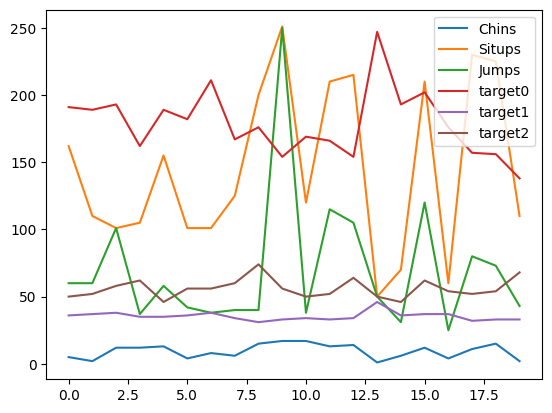

In [19]:
df.plot()

In [38]:
# PyTorch 기본 라이브러리 (텐서 연산, 자동 미분 등 핵심 기능 제공)
import torch

# 신경망 레이어(Linear, Conv 등) 정의용 모듈
import torch.nn as nn

# 활성화 함수(ReLU, Sigmoid 등) 및 신경망 관련 유틸 함수 모음
import torch.nn.functional as F

# 최적화 알고리즘(Adam, SGD 등) 제공
import torch.optim as optim

# Dataset, DataLoader 등 데이터 배치 처리 도구 제공
import torch.utils.data as data_utils

In [40]:
# Linnerud 데이터셋을 위한 다중 출력 회귀 모델 정의
class LinnerudModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinnerudModel, self).__init__()

        # 간단한 MLP 구조 (입력층 → 은닉층 → 출력층)
        self.model = nn.Sequential(
            nn.Linear(input_size, 16),   # 입력 특징을 은닉층 16개 노드로 변환
            nn.ReLU(),                   # 비선형 활성화 함수
            nn.Linear(16, output_size)   # 은닉층에서 최종 예측값 출력 (회귀 출력)
        )
        
    def forward(self, x):
        # 순전파: 입력 x를 모델에 통과시켜 예측값 계산
        output = self.model(x)
        return output

In [22]:
X = torch.Tensor(data.data)
y = torch.Tensor(data.target)

In [23]:
print(X)

tensor([[  5., 162.,  60.],
        [  2., 110.,  60.],
        [ 12., 101., 101.],
        [ 12., 105.,  37.],
        [ 13., 155.,  58.],
        [  4., 101.,  42.],
        [  8., 101.,  38.],
        [  6., 125.,  40.],
        [ 15., 200.,  40.],
        [ 17., 251., 250.],
        [ 17., 120.,  38.],
        [ 13., 210., 115.],
        [ 14., 215., 105.],
        [  1.,  50.,  50.],
        [  6.,  70.,  31.],
        [ 12., 210., 120.],
        [  4.,  60.,  25.],
        [ 11., 230.,  80.],
        [ 15., 225.,  73.],
        [  2., 110.,  43.]])


In [24]:
print(y)

tensor([[191.,  36.,  50.],
        [189.,  37.,  52.],
        [193.,  38.,  58.],
        [162.,  35.,  62.],
        [189.,  35.,  46.],
        [182.,  36.,  56.],
        [211.,  38.,  56.],
        [167.,  34.,  60.],
        [176.,  31.,  74.],
        [154.,  33.,  56.],
        [169.,  34.,  50.],
        [166.,  33.,  52.],
        [154.,  34.,  64.],
        [247.,  46.,  50.],
        [193.,  36.,  46.],
        [202.,  37.,  62.],
        [176.,  37.,  54.],
        [157.,  32.,  52.],
        [156.,  33.,  54.],
        [138.,  33.,  68.]])


In [25]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # train과 test를 8:2로 분할

In [26]:
model = LinnerudModel(3, 3)

In [27]:
n = 0
y = model(X_train[n]).detach() # 더 이상 연산을 추적하지 않는다
print(y, y_train[n])

tensor([ -1.1220, -21.1449, -32.9387]) tensor([191.,  36.,  50.])


In [ ]:
# 모델의 학습 가능한 파라미터를 Adam 최적화 알고리즘으로 업데이트하도록 설정
# lr=0.001 → 학습률(learning rate), 파라미터가 업데이트되는 속도를 결정
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [29]:
print(model)

LinnerudModel(
  (model): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=3, bias=True)
  )
)


In [ ]:
# 회귀 문제에서 사용하는 평균제곱오차(MSE) 손실 함수
criterion = nn.MSELoss()   

n_epochs = 100  # 전체 학습 반복 횟수(epochs)

avg_loss = 0 
for epoch in range(n_epochs):
    for i in range(len(X_train)):
        # 단일 샘플 입력을 모델에 통과시켜 예측값 계산
        y = torch.unsqueeze(model(X_train[i]), dim=0)

        # 단일 타깃(y_train[i])도 형태를 맞추기 위해 (1, output_size)로 변환
        target = torch.unsqueeze(y_train[i], dim=0)

        # 예측값과 실제값 사이의 손실(MSE) 계산
        loss = criterion(y, target)

        optimizer.zero_grad()   # 이전 단계에서 계산된 gradient 초기화
        loss.backward()         # 역전파(backpropagation)로 gradient 계산
        optimizer.step()        # 계산된 gradient를 바탕으로 모델 파라미터 업데이트

        # 전체 샘플의 손실 누적
        avg_loss += loss.data

    # 한 epoch 동안의 평균 손실 계산
    avg_loss /= len(X_train)

    # 10 epoch마다 학습 상황 출력
    if epoch % 10 == 0:
        print('epoch {}th loss: {}'.format(epoch, avg_loss))

epoch 0th loss: 13572.7861328125
epoch 10th loss: 3989.75830078125
epoch 20th loss: 2028.7801513671875
epoch 30th loss: 2010.3818359375
epoch 40th loss: 2006.6201171875
epoch 50th loss: 2002.6163330078125
epoch 60th loss: 1998.5943603515625
epoch 70th loss: 1994.5693359375
epoch 80th loss: 1990.545166015625
epoch 90th loss: 1986.5257568359375


In [31]:
n = 0
y = model(X_train[n]).detach() # 더 이상 연산을 추적하지 않는다
print(y, y_train[n])

tensor([163.0326,  32.3216,  52.8826]) tensor([191.,  36.,  50.])


In [32]:
model = LinnerudModel(3, 3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

n_epochs = 10000 # 10000회 학습

avg_loss = 0 
for epoch in range(n_epochs):
    y = model(X_train)
    loss = criterion(y, y_train).sum()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print('epoch {}th loss: {}'.format(epoch, loss.data))

epoch 0th loss: 10315.095703125
epoch 1000th loss: 1790.9459228515625
epoch 2000th loss: 1609.0263671875
epoch 3000th loss: 1294.886474609375
epoch 4000th loss: 811.5706176757812
epoch 5000th loss: 421.0032653808594
epoch 6000th loss: 226.8197479248047
epoch 7000th loss: 135.05641174316406
epoch 8000th loss: 102.47744750976562
epoch 9000th loss: 96.73310089111328


In [33]:
n = 4
y = model(X_train[n]).detach() # 더 이상 연산을 추적하지 않는다
print(y, y_train[n])

tensor([175.3455,  35.6972,  55.6908]) tensor([138.,  33.,  68.])


In [ ]:
# 입력 3개(신체 측정값), 출력 3개(운동 수행 능력)인 다중 회귀 모델 생성
model = LinnerudModel(3, 3)

# Adam 옵티마이저 설정 (학습률 0.0005)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# 회귀 문제에서 사용하는 MSE(평균제곱오차) 손실 함수
criterion = nn.MSELoss()

# 학습 반복 횟수
n_epochs = 50000

# 학습/테스트 손실 기록 리스트
list_training_loss = []
list_test_loss = []

for epoch in range(n_epochs):

    # 학습 단계
    model.train()                  # 학습 모드
    y = model(X_train)             # 전체 학습 데이터 예측
    loss = criterion(y, y_train).sum()  # 학습 손실 계산 (3개 출력값을 모두 합산)

    optimizer.zero_grad()          # 이전 gradient 초기화
    loss.backward()                # 역전파 수행 (gradient 계산)
    optimizer.step()               # 파라미터 업데이트

    # 평가 단계 (5000 epoch마다 수행)
    if epoch % 5000 == 0:
        model.eval()               # 평가 모드
        y_pred = model(X_test)     # 테스트 데이터 예측
        test_loss = criterion(y_pred, y_test).sum()  # 테스트 손실 계산

        # 학습 상황 출력
        print('epoch {}th training loss: {} test loss: {}'.format(
            epoch, loss.data, test_loss.data))

        # 손실 기록 저장
        list_training_loss.append(loss.data)
        list_test_loss.append(test_loss.data)


epoch 0th training loss: 8842.294921875 test loss: 10594.443359375
epoch 5000th training loss: 1572.0257568359375 test loss: 6267.28466796875
epoch 10000th training loss: 266.9060363769531 test loss: 1693.3804931640625
epoch 15000th training loss: 113.1866226196289 test loss: 597.9928588867188
epoch 20000th training loss: 113.1866226196289 test loss: 598.2152099609375
epoch 25000th training loss: 113.18661499023438 test loss: 598.2108764648438
epoch 30000th training loss: 113.18660736083984 test loss: 598.2113647460938
epoch 35000th training loss: 113.18653106689453 test loss: 598.210693359375
epoch 40000th training loss: 113.1865234375 test loss: 598.2131958007812
epoch 45000th training loss: 113.18683624267578 test loss: 598.2163696289062


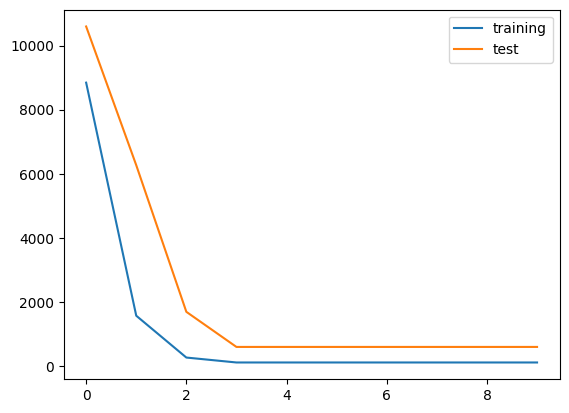

In [35]:
import matplotlib.pyplot as plt

plt.plot(list_training_loss, label='training')
plt.plot(list_test_loss, label='test')
plt.legend()
plt.show()

In [36]:
from sklearn.metrics import r2_score

with torch.no_grad():
    y_pred = model(X_test)
    score = r2_score(y_test, y_pred)
    print(score)

-0.46337056159973145


In [37]:
class MAPELoss(nn.Module):
    def __init__(self):
        super(MAPELoss, self).__init__()

    def forward(self, y_pred, y_true):
        epsilon = 1e-8  
        loss = torch.mean(torch.abs((y_true - y_pred) / (y_true + epsilon)))
        return loss * 100  
    
mape_loss = MAPELoss()
y_pred = model(X_test).squeeze()
loss_value = mape_loss(y_pred, y_test)
print(f"MAPE Loss: {loss_value.item():.4f}%")

MAPE Loss: 15.9361%
